In [1]:
'''
Code flow:

1. Get the masks generated:
    - Store the masks in an array of shape - 12*11*224*224
    - Save these features with the complete features.
    
2. Get the features of the masks:
'''


'\nCode flow:\n\n1. Get the masks generated:\n    - Store the masks in an array of shape - 12*11*224*224\n    - Save these features with the complete features.\n    \n2. Get the features of the masks:\n'

In [2]:
import torch

import numpy as np
import cv2
import matplotlib.pyplot as plt

def rescale_masks(mask):

    # First, ensure mask isn't None
    if mask is not None:
        # Squeeze out the first dimension
        mask_squeezed = mask.squeeze().astype(np.uint8)
        
        # Ensure mask values are 0 or 1 (binary). This is just a precaution.
        mask_squeezed = np.where(mask_squeezed > 0, 1, 0).astype(np.uint8)

        # Rescale the mask to 224x224
        rescaled_mask = cv2.resize(mask_squeezed, (320, 240), interpolation=cv2.INTER_NEAREST)
        mask_bool = rescaled_mask.astype(bool)
        return mask_bool
    
    else:
        return None


def extract_sam_masks(ml_elements, gif, feat):
    """
    ml_elements['clip']         : clip model (modified by ViPLO) to be used for extracting features
    ml_elements['clip_preproc'] : pre-processing function to be used to pre-process the features
    video                       : Object having the video
    feat                        : The current extracted feats also having the tracked bounding boxes
    """
    
    # Flow - Get the bounding boxes, Get the image into the format needed, get it pre-processed
    # Get the bounding box features, Return it as a feature matrix
    
    num_obj = int(feat['num_obj'])
    
    img_width, img_height = feat['metadata']['frame_width'], feat['metadata']['frame_height']

    img_dim = (img_width, img_height)
    bbox_tensors = feat['bboxes'][:num_obj, :]
    
    # sam_masks = torch.zeros(12, 11, 320, 240, dtype=torch.bool)
    
    sam_masks = np.zeros((12, 11, 240, 320) ,dtype=bool)
    sam_predictor = ml_elements['SAM_predictor']

    for i in range(11):
        temp_gif = gif[i].convert('RGB')
        frame = np.asarray(temp_gif)
               
        sam_predictor.set_image(frame)
        
        for j in range(num_obj):
            
            temp_box = bbox_tensors[j, i].numpy()
            
            masks, _, _ = sam_predictor.predict(
                                                    point_coords=None,
                                                    point_labels=None,
                                                    box=temp_box,
                                                    multimask_output=False,
                                                )
            rescaled_masks = rescale_masks(masks)
            
            if type(rescaled_masks) is not None:
                sam_masks[j, i, :, :] = rescaled_masks
    
    feat['sam_masks'] = sam_masks

    return feat

In [3]:
# Create all the various ml_elements
ml_elements = {}
device = torch.device('cuda:0')
ml_elements['device'] = device

import sys
sys.path.append("/workspace/work/ral_revise_and_resubmit/segment-anything")

from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "/workspace/work/ral_revise_and_resubmit/segment-anything/sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam_device = "cuda:1"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)
ml_elements['SAM_predictor'] = predictor


In [4]:
from PIL import Image, ImageSequence
import torch

def load_gif_frames(gif_path):
    """
    Load the frames of a GIF into a list.

    Args:
    - gif_path (str): Path to the GIF file.

    Returns:
    - List[Image.Image]: List of PIL Image objects representing the frames.
    """
    with Image.open(gif_path) as im:
        frames = [frame.copy() for frame in ImageSequence.Iterator(im)]
    return frames



from glob import glob as glob

old_feat_files = '/workspace/data/data_folder/o2o/ral_features/full_features/*.pt'
file_list = glob(old_feat_files)

from tqdm import tqdm as tqdm
gif_folder = '/workspace/data/data_folder/o2o/gifs_11'


current_file = file_list[110]

current_dict = torch.load(current_file)

yt_id = current_dict['metadata']['yt_id']
frame_index = current_dict['metadata']['frame no.']

window_size = 5

# Loading the gif    
filename = yt_id + '_' + str(frame_index) + '_' + str(window_size) + '.gif'
import os
file_location = os.path.join(gif_folder, filename)

gif_frames = load_gif_frames(file_location)

success = extract_sam_masks(ml_elements, gif_frames, current_dict)

<ipython-input-5-704a3c59fe2c>:14: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if mask.dtype != np.bool:


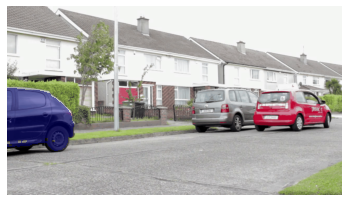

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def overlay_mask_on_image(img, mask):
    """
    Overlays a boolean mask on a PIL image and visualizes it.

    Parameters:
    - img: A PIL image.
    - mask: A 2D numpy array of boolean datatype representing the mask.
    """
    
    if mask.dtype != np.bool:
        raise ValueError("The input mask is not of boolean datatype.")
    
    # Resize mask to match image dimensions
    mask_pil = Image.fromarray(mask.astype(np.uint8) * 255)  # Convert to 0-255 scale PIL Image
    mask_resized_pil = mask_pil.resize(img.size)  # Resize to match the image
    mask_resized = np.array(mask_resized_pil) > 127  # Convert back to boolean numpy array

    # Display the PIL image
    plt.imshow(img)

    # Overlay the resized mask
    plt.imshow(np.ma.masked_where(mask_resized == False, mask_resized), cmap='jet', alpha=0.5)

    plt.axis('off')  # Hide axis labels and ticks
    plt.show()



overlay_mask_on_image( gif_frames[5], success['sam_masks'][2,0])


In [6]:
current_dict.keys()

dict_keys(['legend', 'metadata', 'num_obj', 'bboxes', 'lr', 'mr', 'cr', 'object_pairs', 'num_relation', 'geometric_feature', '2d_cnn_feature_map', 'object_2d_cnn_feature', 'iou', 'distance', 'relative_spatial_feature', 'i3d_feature_map', 'object_i3d_feature', 'motion_feature', 'sam_masks'])

In [ ]:
current_dict[]